## Import necessary library


In [757]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import os
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader

## Get File path and load the csv data


In [ ]:
from util.data_path import soybean_price_avg_year_fix as data_file

In [759]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"]).astype(str) + "-" + long["month"].astype(str).str.zfill(2) + "-01"
)
long = long.set_index("date").sort_index()

In [760]:
# Rolling window parameters
WINDOW_SIZE = 8  # 5-year training window
FIRST_TRAIN_START = 2004  # First training window starts in 2004
LAST_AVAILABLE_YEAR = long.index.year.max()  # Get the last available year in data

print(f"Data available from {long.index.year.min()} to {LAST_AVAILABLE_YEAR}")
print(f"Using {WINDOW_SIZE}-year rolling window approach")
print(
    f"First training window: {FIRST_TRAIN_START}-{FIRST_TRAIN_START + WINDOW_SIZE - 1}"
)
print(f"Last possible prediction year: {LAST_AVAILABLE_YEAR}")

# Calculate how many windows we can create
num_windows = LAST_AVAILABLE_YEAR - (FIRST_TRAIN_START + WINDOW_SIZE - 1)
print(f"Total number of rolling windows: {num_windows}")

# Initialize lists to store results from all windows
all_forecasts = []
all_actuals = []
all_errors = []
all_window_info = []

Data available from 2004 to 2024
Using 8-year rolling window approach
First training window: 2004-2011
Last possible prediction year: 2024
Total number of rolling windows: 13


## Rolling Window Training and Prediction Approach

**Training Strategy**: Using a rolling 5-year training window for improved model robustness

- **Window Size**: 5 years of training data
- **Approach**:
  - Train on years N to N+4, predict year N+5
  - Shift window by 1 year: Train on years N+1 to N+5, predict year N+6
  - Continue until all available data is used
- **Example**: 2004-2008 → predict 2009, then 2005-2009 → predict 2010, etc.

This approach provides multiple predictions and allows for comprehensive model evaluation across different time periods.


In [761]:
# Rolling window training and prediction
print("Starting rolling window analysis...")
print("=" * 50)

for window_idx in range(num_windows):
    # Calculate years for current window
    train_start = FIRST_TRAIN_START + window_idx
    train_end = train_start + WINDOW_SIZE - 1
    pred_year = train_end + 1

    print(f"\nWindow {window_idx + 1}/{num_windows}:")
    print(f"Training: {train_start}-{train_end} | Predicting: {pred_year}")

    # Prepare training data for current window
    train = long[(long.index.year >= train_start) & (long.index.year <= train_end)][
        "price"
    ].to_frame()

    # Get actual data for prediction year
    future = long[long.index.year == pred_year]["price"].to_frame()

    # Check if we have data for the prediction year
    if future.empty:
        print(f"No data available for prediction year {pred_year}, skipping...")
        continue

    # Scale the training data
    scaler = MinMaxScaler()
    train["scaled"] = scaler.fit_transform(train[["price"]])
    series = train["scaled"].values.astype(np.float32)

    print(f"Training data: {len(train)} months ({len(train) / 12:.1f} years)")
    print(f"Prediction data: {len(future)} months")

Starting rolling window analysis...

Window 1/13:
Training: 2004-2011 | Predicting: 2012
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 2/13:
Training: 2005-2012 | Predicting: 2013
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 3/13:
Training: 2006-2013 | Predicting: 2014
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 4/13:
Training: 2007-2014 | Predicting: 2015
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 5/13:
Training: 2008-2015 | Predicting: 2016
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 6/13:
Training: 2009-2016 | Predicting: 2017
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 7/13:
Training: 2010-2017 | Predicting: 2018
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 8/13:
Training: 2011-2018 | Predicting: 2019
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 9/13:
Training: 2012

In [762]:
# Import LSTM classes and set parameters
from util.manystep_lstm_class import SeqDataset
from util.manystep_lstm_class import LSTMRegressor

# LSTM Model Parameters
SEQ_LEN = 12  # Input sequence length (12 months)
PRED_LEN = 12  # Prediction length (12 months)
EPOCHS = 300  # Training epochs per window

print(f"LSTM Parameters:")
print(f"Sequence Length: {SEQ_LEN} months")
print(f"Prediction Length: {PRED_LEN} months")
print(f"Training Epochs per window: {EPOCHS}")
print(f"Hidden units: 32, Layers: 3")

LSTM Parameters:
Sequence Length: 12 months
Prediction Length: 12 months
Training Epochs per window: 300
Hidden units: 32, Layers: 3


In [763]:
# Create dataset and data loader for current window
train_ds = SeqDataset(series, seq_len=SEQ_LEN, pred_len=PRED_LEN)
train_loader = DataLoader(train_ds, batch_size=len(train_ds), shuffle=True)

# Initialize and train LSTM model for current window
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMRegressor(hidden=32, layers=3, pred_len=PRED_LEN).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# Training loop
model.train()
for ep in range(EPOCHS):
    for seq, targ in train_loader:
        seq = seq.to(device)
        targ = targ.to(device)
        pred = model(seq)
        loss = criterion(pred, targ)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print(f"Model training completed for window {window_idx + 1}")

Model training completed for window 13


In [764]:
# Make predictions for the current window
last_window_scaled = series[-SEQ_LEN:].copy()

model.eval()
with torch.no_grad():
    x = (
        torch.tensor(last_window_scaled, dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(-1)
        .to(device)
    )
    pred_12 = model(x).cpu().numpy().reshape(-1)
    forecast_scaled = pred_12

    # Convert predictions back to original scale
    forecast_values = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).reshape(
        -1
    )

    # Create forecast series with proper dates
    months = pd.date_range(start=f"{pred_year}-01-01", periods=PRED_LEN, freq="MS")
    forecast = pd.Series(forecast_values, index=months, name="forecast_price")

    # Store results for this window
    window_info = {
        "window_idx": window_idx + 1,
        "train_start": train_start,
        "train_end": train_end,
        "pred_year": pred_year,
        "forecast": forecast,
        "actual": future["price"],
        "train_size": len(train),
    }

    all_window_info.append(window_info)
    all_forecasts.append(forecast)
    all_actuals.append(future["price"])

    # Calculate errors for this window
    error = future["price"] - forecast
    abs_error = abs(error)
    mae_window = mean_absolute_error(future["price"], forecast)

    all_errors.append(
        {
            "window": window_idx + 1,
            "pred_year": pred_year,
            "mae": mae_window,
            "error_series": error,
            "abs_error_series": abs_error,
        }
    )

    print(f"Window {window_idx + 1} completed - MAE: {mae_window:.4f}")

print("\n" + "=" * 50)
print("Rolling window analysis completed!")
print(f"Total windows processed: {len(all_window_info)}")
print(f"Years predicted: {[info['pred_year'] for info in all_window_info]}")

Window 13 completed - MAE: 1.8150

Rolling window analysis completed!
Total windows processed: 1
Years predicted: [2024]


In [765]:
# Consolidate results from all rolling windows
print("\n" + "=" * 60)
print("ROLLING WINDOW ANALYSIS SUMMARY")
print("=" * 60)

# Combine all forecasts and actuals
combined_forecasts = pd.concat(all_forecasts)
combined_actuals = pd.concat(all_actuals)

# Create comprehensive comparison dataframe
cmp = pd.concat(
    [combined_actuals.rename("actual"), combined_forecasts.rename("forecast_price")],
    axis=1,
)
cmp = cmp.dropna()  # Remove any NaN values

# Overall error analysis
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
abs_pct_error = abs_error / cmp["actual"] * 100

# Overall metrics
mae_overall = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
mape_overall = abs_pct_error.mean()
accuracy_overall = 100 - (mae_overall / cmp["actual"].mean() * 100)

print(f"\nOVERALL PERFORMANCE ACROSS ALL WINDOWS:")
print(f"Total predictions made: {len(cmp)} months across {len(all_window_info)} years")
print(f"Overall MAE: {mae_overall:.6f}")
print(f"Overall MAPE: {mape_overall:.4f}%")
print(f"Overall Accuracy: {accuracy_overall:.2f}%")

# Window-by-window performance
print(f"\nWINDOW-BY-WINDOW PERFORMANCE:")
print(f"{'Window':<8} {'Year':<6} {'MAE':<12} {'Train Period':<15}")
print("-" * 50)
for i, err_info in enumerate(all_errors):
    window_info = all_window_info[i]
    train_period = f"{window_info['train_start']}-{window_info['train_end']}"
    print(
        f"{err_info['window']:<8} {err_info['pred_year']:<6} {err_info['mae']:<12.6f} {train_period:<15}"
    )

# Calculate average MAE across all windows
avg_mae = np.mean([err["mae"] for err in all_errors])
print(f"\nAverage MAE across all windows: {avg_mae:.6f}")
print(f"MAE Standard Deviation: {np.std([err['mae'] for err in all_errors]):.6f}")


ROLLING WINDOW ANALYSIS SUMMARY

OVERALL PERFORMANCE ACROSS ALL WINDOWS:
Total predictions made: 12 months across 1 years
Overall MAE: 1.815024
Overall MAPE: 16.9351%
Overall Accuracy: 83.18%

WINDOW-BY-WINDOW PERFORMANCE:
Window   Year   MAE          Train Period   
--------------------------------------------------
13       2024   1.815024     2016-2023      

Average MAE across all windows: 1.815024
MAE Standard Deviation: 0.000000


In [766]:
# Import LSTM classes and set parameters
from util.manystep_lstm_class import SeqDataset
from util.manystep_lstm_class import LSTMRegressor

# LSTM Model Parameters
SEQ_LEN = 12  # Input sequence length (12 months)
PRED_LEN = 12  # Prediction length (12 months)
EPOCHS = 300  # Training epochs per window

print(f"LSTM Parameters:")
print(f"Sequence Length: {SEQ_LEN} months")
print(f"Prediction Length: {PRED_LEN} months")
print(f"Training Epochs per window: {EPOCHS}")
print(f"Hidden units: 32, Layers: 3")

LSTM Parameters:
Sequence Length: 12 months
Prediction Length: 12 months
Training Epochs per window: 300
Hidden units: 32, Layers: 3


# Rolling Window LSTM Training and Prediction


In [767]:
# Display consolidated results from all rolling windows
print("\n--- Consolidated Actual vs Forecast Results ---")
print(f"Total predictions: {len(cmp)} months across {len(all_window_info)} years")
print("\nSample of results:")
print(cmp.head(10).round(2))
print("...")
print(cmp.tail(10).round(2))


--- Consolidated Actual vs Forecast Results ---
Total predictions: 12 months across 1 years

Sample of results:
            actual  forecast_price
2024-01-01   10.28           12.23
2024-02-01   10.32           12.53
2024-03-01   10.27           11.99
2024-04-01   10.14           12.26
2024-05-01   10.74           11.34
2024-06-01   12.14           11.47
2024-07-01   12.45           10.13
2024-08-01   12.08            9.65
2024-09-01   10.81            8.88
2024-10-01    9.86            8.47
...
            actual  forecast_price
2024-03-01   10.27           11.99
2024-04-01   10.14           12.26
2024-05-01   10.74           11.34
2024-06-01   12.14           11.47
2024-07-01   12.45           10.13
2024-08-01   12.08            9.65
2024-09-01   10.81            8.88
2024-10-01    9.86            8.47
2024-11-01    9.77            7.86
2024-12-01   10.62            8.09


## Save the Forecasted Price LSTM Model


In [768]:
from util.data_path import LSTM_5T_for
from datetime import datetime

In [769]:
# Verify rolling window training data and results
print(f"Rolling Window Analysis Summary:")
print(f"Number of windows: {len(all_window_info)}")
print(f"Total predictions: {len(cmp)} months")
print(f"Years covered: {cmp.index.year.min()} to {cmp.index.year.max()}")
print(f"Average training period per window: {WINDOW_SIZE} years")

print(f"\nWindow details:")
for info in all_window_info:
    train_months = info["train_size"]
    pred_months = len(info["forecast"])
    print(
        f"  Window {info['window_idx']}: Train {info['train_start']}-{info['train_end']} ({train_months} months) -> Predict {info['pred_year']} ({pred_months} months)"
    )

Rolling Window Analysis Summary:
Number of windows: 1
Total predictions: 12 months
Years covered: 2024 to 2024
Average training period per window: 8 years

Window details:
  Window 13: Train 2016-2023 (96 months) -> Predict 2024 (12 months)


In [770]:
# Save rolling window forecast results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_rolling_window_forecast.txt"
filepath = LSTM_5T_for / filename

# Save comprehensive forecast data to text file
with open(filepath, "w", encoding="utf-8") as f:
    f.write(
        f"LSTM Rolling Window Forecast Results for {data_file.parent.name.capitalize()} Prices - {timestamp}\n"
    )
    f.write("=" * 80 + "\n\n")

    f.write("Rolling Window Configuration:\n")
    f.write("-" * 30 + "\n")
    f.write(f"Window Size: {WINDOW_SIZE} years\n")
    f.write(f"Total Windows: {len(all_window_info)}\n")
    f.write(
        f"First Training Period: {all_window_info[0]['train_start']}-{all_window_info[0]['train_end']}\n"
    )
    f.write(
        f"Last Training Period: {all_window_info[-1]['train_start']}-{all_window_info[-1]['train_end']}\n"
    )
    f.write(f"Prediction Years: {[info['pred_year'] for info in all_window_info]}\n\n")

    # Window-by-window results
    for i, info in enumerate(all_window_info):
        f.write(
            f"Window {info['window_idx']} - Training: {info['train_start']}-{info['train_end']}, Predicting: {info['pred_year']}\n"
        )
        f.write("-" * 50 + "\n")
        for date, price in info["forecast"].items():
            f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")
        f.write(f"\nWindow {info['window_idx']} Statistics:\n")
        f.write(
            f"Mean: {info['forecast'].mean():.2f}, Min: {info['forecast'].min():.2f}, Max: {info['forecast'].max():.2f}\n\n"
        )

    f.write("Overall Consolidated Statistics:\n")
    f.write("-" * 30 + "\n")
    f.write(f"Total Predictions: {len(combined_forecasts)} months\n")
    f.write(f"Overall Mean Price: {combined_forecasts.mean():.2f}\n")
    f.write(f"Overall Min Price: {combined_forecasts.min():.2f}\n")
    f.write(f"Overall Max Price: {combined_forecasts.max():.2f}\n")
    f.write(f"Overall Standard Deviation: {combined_forecasts.std():.2f}\n")

print(f"Rolling window forecast results saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Rolling window forecast results saved to: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T\corn_rolling_window_forecast.txt
File size: 951 bytes


## Compare The Error of a predicted data in a table format


In [771]:
# Comprehensive error analysis for rolling window results
print("\n=== ROLLING WINDOW ERROR ANALYSIS ===")

# Overall consolidated errors
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
abs_pct_error = abs_error / cmp["actual"] * 100
mae_lstm = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
mape_lstm = abs_pct_error.mean()

print(f"\nCONSOLIDATED RESULTS ACROSS ALL WINDOWS:")
print(f"Total predictions: {len(cmp)} months")
print(f"Overall MAE: {mae_lstm:.6f}")
print(f"Overall MAPE: {mape_lstm:.4f}%")
print(f"Overall Accuracy: {100 - (mae_lstm / cmp['actual'].mean() * 100):.2f}%")

# Window-by-window detailed analysis
print(f"\nWINDOW-BY-WINDOW ERROR ANALYSIS:")
print(
    f"{'Window':<8} {'Year':<6} {'MAE':<12} {'MAPE':<12} {'Accuracy':<10} {'Train Period':<15}"
)
print("-" * 75)

window_maes = []
window_mapes = []
window_accuracies = []

for i, info in enumerate(all_window_info):
    actual_vals = info["actual"]
    forecast_vals = info["forecast"]

    window_error = actual_vals - forecast_vals
    window_abs_error = abs(window_error)
    window_mae = mean_absolute_error(actual_vals, forecast_vals)
    window_mape = (window_abs_error / actual_vals * 100).mean()
    window_accuracy = 100 - (window_mae / actual_vals.mean() * 100)

    window_maes.append(window_mae)
    window_mapes.append(window_mape)
    window_accuracies.append(window_accuracy)

    train_period = f"{info['train_start']}-{info['train_end']}"
    print(
        f"{info['window_idx']:<8} {info['pred_year']:<6} {window_mae:<12.6f} {window_mape:<12.4f}% {window_accuracy:<10.2f}% {train_period:<15}"
    )

# Cross-window statistics
print(f"\nCROSS-WINDOW STATISTICS:")
print(f"Average MAE across windows: {np.mean(window_maes):.6f}")
print(f"MAE Standard Deviation: {np.std(window_maes):.6f}")
print(
    f"Best Window MAE: {np.min(window_maes):.6f} (Window {np.argmin(window_maes) + 1})"
)
print(
    f"Worst Window MAE: {np.max(window_maes):.6f} (Window {np.argmax(window_maes) + 1})"
)
print(f"Average MAPE across windows: {np.mean(window_mapes):.4f}%")
print(f"Average Accuracy across windows: {np.mean(window_accuracies):.2f}%")

# Monthly breakdown for consolidated results
print(f"\nCONSOLIDATED MONTHLY ERRORS:")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "abs_pct_error": abs_pct_error,
    }
)
print(error_df.round(4))


=== ROLLING WINDOW ERROR ANALYSIS ===

CONSOLIDATED RESULTS ACROSS ALL WINDOWS:
Total predictions: 12 months
Overall MAE: 1.815024
Overall MAPE: 16.9351%
Overall Accuracy: 83.18%

WINDOW-BY-WINDOW ERROR ANALYSIS:
Window   Year   MAE          MAPE         Accuracy   Train Period   
---------------------------------------------------------------------------
13       2024   1.815024     16.9351     % 83.18     % 2016-2023      

CROSS-WINDOW STATISTICS:
Average MAE across windows: 1.815024
MAE Standard Deviation: 0.000000
Best Window MAE: 1.815024 (Window 1)
Worst Window MAE: 1.815024 (Window 1)
Average MAPE across windows: 16.9351%
Average Accuracy across windows: 83.18%

CONSOLIDATED MONTHLY ERRORS:
            actual  forecast   error  abs_error  abs_pct_error
2024-01-01   10.28   12.2285 -1.9485     1.9485        18.9543
2024-02-01   10.32   12.5305 -2.2105     2.2105        21.4192
2024-03-01   10.27   11.9891 -1.7191     1.7191        16.7392
2024-04-01   10.14   12.2554 -2.1154   

## Plot The predicted data compare to an actual data


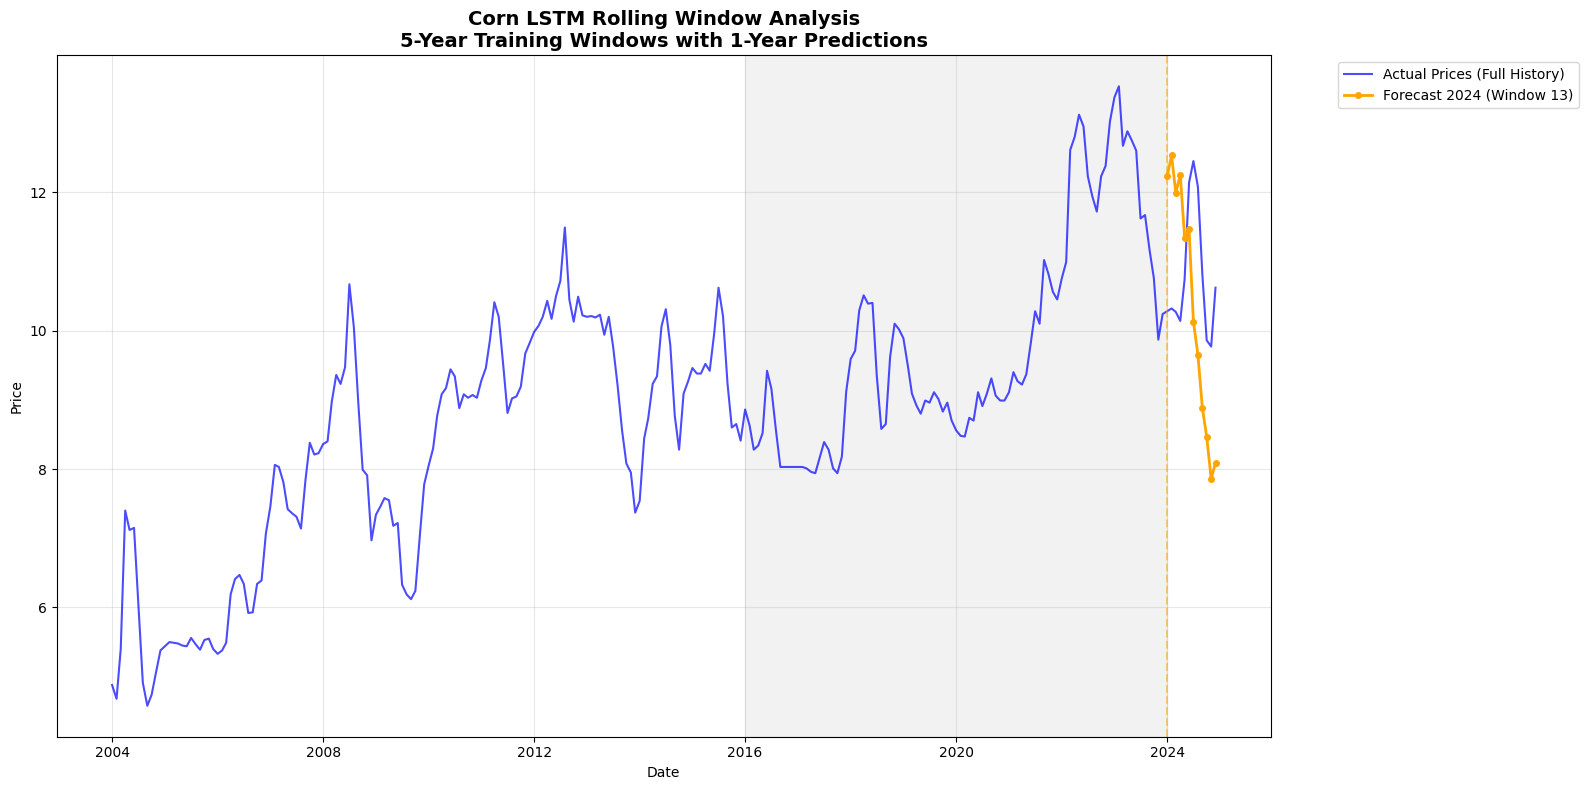

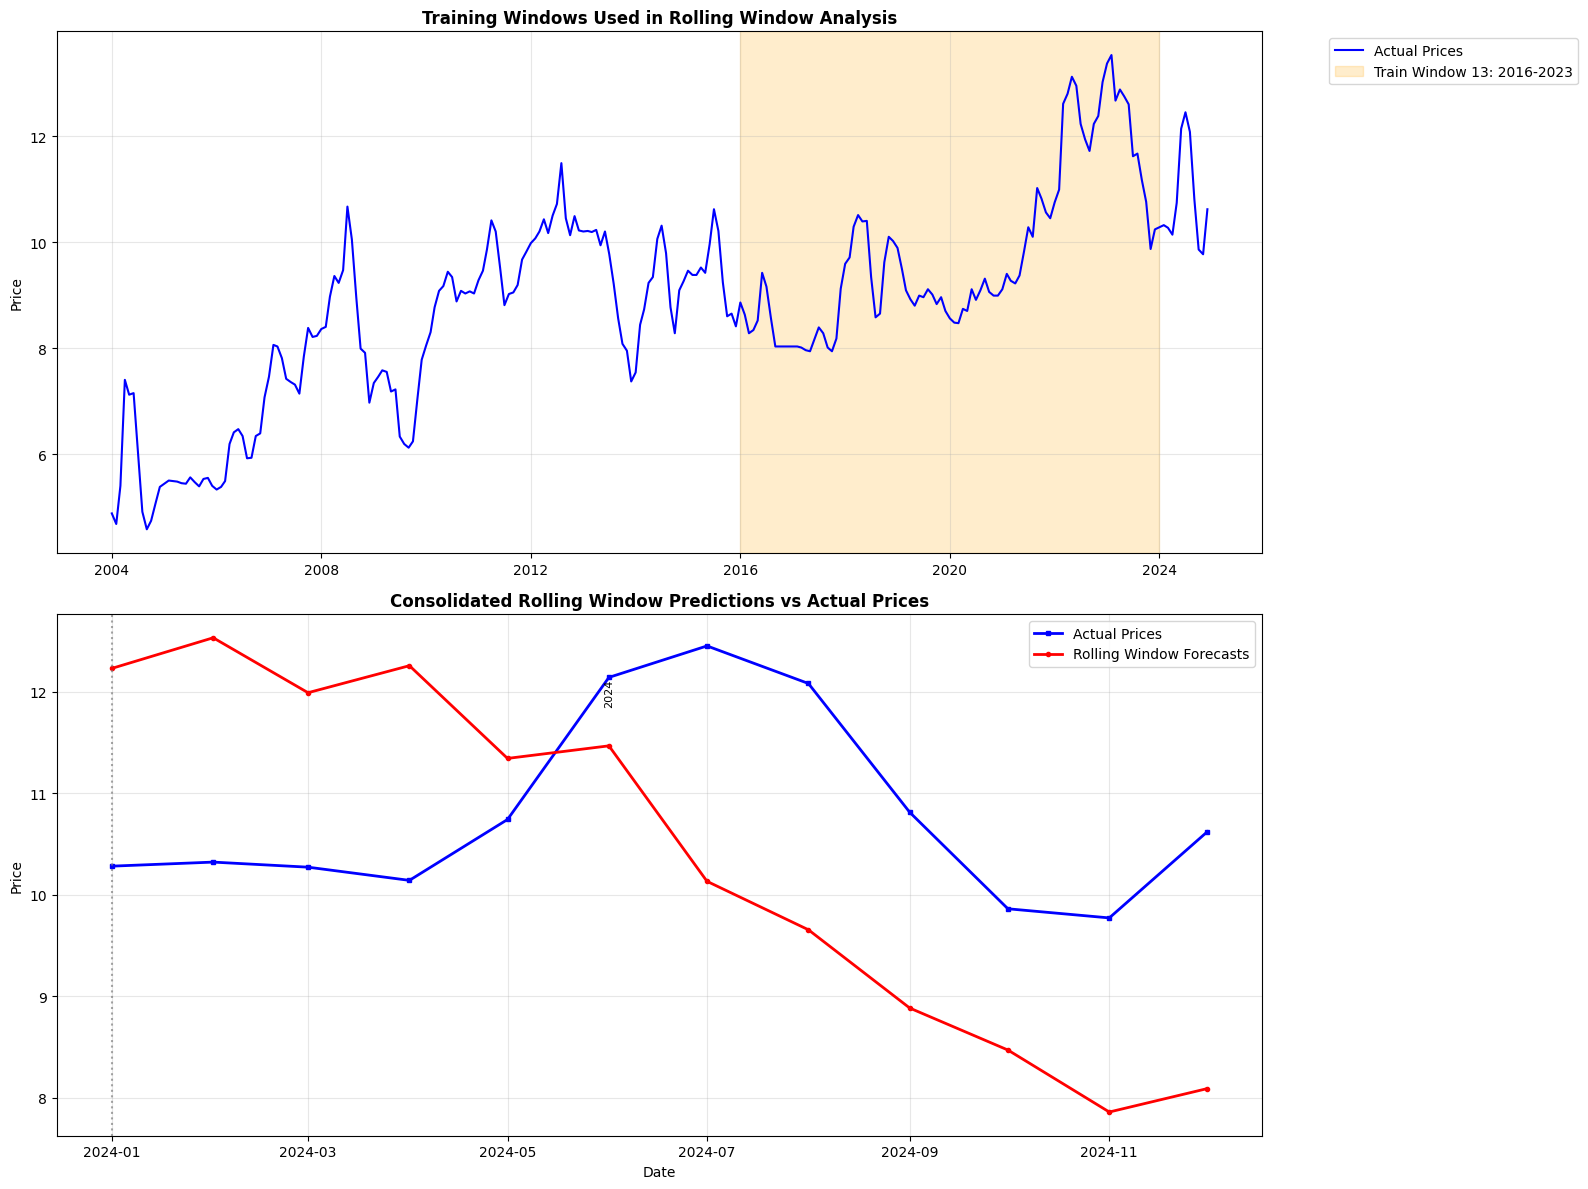

In [772]:
# Plot rolling window results
plt.figure(figsize=(16, 8))

# Plot actual prices for entire period
plt.plot(
    long.index,
    long["price"],
    label="Actual Prices (Full History)",
    color="blue",
    alpha=0.7,
)

# Plot forecasts from all windows
colors = ["orange", "red", "green", "purple", "brown", "pink", "gray", "olive", "cyan"]
for i, info in enumerate(all_window_info):
    color = colors[i % len(colors)]
    plt.plot(
        info["forecast"].index,
        info["forecast"],
        label=f"Forecast {info['pred_year']} (Window {info['window_idx']})",
        color=color,
        linewidth=2,
        marker="o",
        markersize=4,
    )

    # Add vertical line to mark prediction start
    plt.axvline(
        x=pd.Timestamp(f"{info['pred_year']}-01-01"),
        color=color,
        linestyle="--",
        alpha=0.5,
    )

# Add training windows as background shading
for i, info in enumerate(all_window_info):
    train_start_date = pd.Timestamp(f"{info['train_start']}-01-01")
    train_end_date = pd.Timestamp(f"{info['train_end']}-12-31")
    plt.axvspan(train_start_date, train_end_date, alpha=0.1, color="gray")

plt.title(
    f"{data_file.parent.name.capitalize()} LSTM Rolling Window Analysis\n"
    f"5-Year Training Windows with 1-Year Predictions",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Additional plot: Show training windows and predictions separately
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Top plot: Training periods and actual data
ax1.plot(long.index, long["price"], label="Actual Prices", color="blue", linewidth=1.5)
for i, info in enumerate(all_window_info):
    train_start_date = pd.Timestamp(f"{info['train_start']}-01-01")
    train_end_date = pd.Timestamp(f"{info['train_end']}-12-31")
    ax1.axvspan(
        train_start_date,
        train_end_date,
        alpha=0.2,
        color=colors[i % len(colors)],
        label=f"Train Window {info['window_idx']}: {info['train_start']}-{info['train_end']}",
    )

ax1.set_title(
    "Training Windows Used in Rolling Window Analysis", fontsize=12, fontweight="bold"
)
ax1.set_ylabel("Price")
ax1.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax1.grid(True, alpha=0.3)

# Bottom plot: Predictions vs Actual
ax2.plot(
    cmp.index,
    cmp["actual"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
    markersize=3,
)
ax2.plot(
    cmp.index,
    cmp["forecast_price"],
    label="Rolling Window Forecasts",
    color="red",
    linewidth=2,
    marker="o",
    markersize=3,
)

# Mark each prediction year
for info in all_window_info:
    ax2.axvline(
        x=pd.Timestamp(f"{info['pred_year']}-01-01"),
        color="gray",
        linestyle=":",
        alpha=0.7,
    )
    ax2.text(
        pd.Timestamp(f"{info['pred_year']}-06-01"),
        ax2.get_ylim()[1] * 0.95,
        f"{info['pred_year']}",
        rotation=90,
        ha="center",
        va="top",
        fontsize=8,
    )

ax2.set_title(
    "Consolidated Rolling Window Predictions vs Actual Prices",
    fontsize=12,
    fontweight="bold",
)
ax2.set_xlabel("Date")
ax2.set_ylabel("Price")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Rolling Window Analysis Results and Visualization

The following sections present the results of the rolling window LSTM analysis, including:

1. **Performance Comparison**: Window-by-window vs consolidated results
2. **Visualization**: Multiple plots showing training windows and predictions
3. **Error Analysis**: Comprehensive error metrics across all windows
4. **File Outputs**: Saved forecasts and error metrics

This approach provides more robust evaluation by testing the model's performance across multiple time periods rather than a single train-test split.


## Save the model Error Analysis to a file


In [773]:
from util.data_path import LSTM_5T_err

In [774]:
crop_name = data_file.parent.name
filename = f"{crop_name}_error_metrics.txt"
filepath = LSTM_5T_err / filename

In [775]:
# Save comprehensive rolling window error analysis
crop_name = data_file.parent.name
filename = f"{crop_name}_rolling_window_error_metrics.txt"
filepath = LSTM_5T_err / filename

# Calculate consolidated metrics
mae_value = mae_lstm
mape_value = mape_lstm
accuracy = 100 - (mae_lstm / cmp["actual"].mean() * 100)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save comprehensive metrics to text file
with open(filepath, "w", encoding="utf-8") as f:
    f.write(
        f"LSTM Rolling Window Model Evaluation for {crop_name.capitalize()} - {timestamp}\n"
    )
    f.write("=" * 80 + "\n\n")

    f.write("Rolling Window Configuration:\n")
    f.write("-" * 30 + "\n")
    f.write(f"Window Size: {WINDOW_SIZE} years\n")
    f.write(f"Total Windows Processed: {len(all_window_info)}\n")
    f.write(
        f"LSTM Parameters: SEQ_LEN={SEQ_LEN}, PRED_LEN={PRED_LEN}, EPOCHS={EPOCHS}\n"
    )
    f.write(f"Model Architecture: 32 hidden units, 3 layers\n\n")

    f.write("Overall Consolidated Metrics:\n")
    f.write("-" * 30 + "\n")
    f.write(
        f"Total Predictions: {len(cmp)} months across {len(all_window_info)} years\n"
    )
    f.write(f"Overall Mean Absolute Error (MAE): {mae_value:.6f}\n")
    f.write(f"Overall Mean Absolute Percentage Error (MAPE): {mape_value:.4f}%\n")
    f.write(f"Overall Model Accuracy: {accuracy:.2f}%\n\n")

    f.write("Window-by-Window Performance:\n")
    f.write("-" * 40 + "\n")
    f.write(
        f"{'Window':<8} {'Year':<6} {'MAE':<12} {'MAPE':<12} {'Accuracy':<10} {'Train Period':<15}\n"
    )
    f.write("-" * 75 + "\n")

    for i, info in enumerate(all_window_info):
        actual_vals = info["actual"]
        forecast_vals = info["forecast"]
        window_mae = mean_absolute_error(actual_vals, forecast_vals)
        window_abs_error = abs(actual_vals - forecast_vals)
        window_mape = (window_abs_error / actual_vals * 100).mean()
        window_accuracy = 100 - (window_mae / actual_vals.mean() * 100)
        train_period = f"{info['train_start']}-{info['train_end']}"

        f.write(
            f"{info['window_idx']:<8} {info['pred_year']:<6} {window_mae:<12.6f} {window_mape:<12.4f}% {window_accuracy:<10.2f}% {train_period:<15}\n"
        )

    f.write(f"\nCross-Window Statistics:\n")
    f.write("-" * 25 + "\n")
    f.write(f"Average MAE across windows: {np.mean(window_maes):.6f}\n")
    f.write(f"MAE Standard Deviation: {np.std(window_maes):.6f}\n")
    f.write(
        f"Best Window MAE: {np.min(window_maes):.6f} (Window {np.argmin(window_maes) + 1})\n"
    )
    f.write(
        f"Worst Window MAE: {np.max(window_maes):.6f} (Window {np.argmax(window_maes) + 1})\n"
    )
    f.write(f"Average MAPE across windows: {np.mean(window_mapes):.4f}%\n")
    f.write(f"Average Accuracy across windows: {np.mean(window_accuracies):.2f}%\n\n")

    f.write("Consolidated Monthly Evaluation:\n")
    f.write("-" * 30 + "\n")
    f.write(
        f"{'Date':<12} {'Actual':<10} {'Forecast':<10} {'Error':<10} {'Abs Error':<10} {'% Error':<10}\n"
    )
    f.write("-" * 75 + "\n")

    for date, row in error_df.iterrows():
        month_label = date.strftime("%Y-%m")
        f.write(
            f"{month_label:<12} {row['actual']:<10.2f} {row['forecast']:<10.2f} {row['error']:<10.4f} {row['abs_error']:<10.4f} {row['abs_pct_error']:<10.2f}%\n"
        )

    f.write(f"\nRolling Window Training Details:\n")
    f.write("-" * 30 + "\n")
    for info in all_window_info:
        f.write(
            f"Window {info['window_idx']}: Train on {info['train_start']}-{info['train_end']} ({info['train_size']} months) -> Predict {info['pred_year']} (12 months)\n"
        )

print(f"Rolling window evaluation metrics saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

print(f"=== ROLLING WINDOW ANALYSIS COMPLETE ===")
print(
    f"Successfully trained {len(all_window_info)} models using 5-year rolling windows"
)
print(
    f"Generated predictions for years: {[info['pred_year'] for info in all_window_info]}"
)
print(f"Overall model performance: {accuracy:.2f}% accuracy, {mae_value:.6f} MAE")

Rolling window evaluation metrics saved to: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\error_record\LSTM-5T\corn_rolling_window_error_metrics.txt
File size: 2378 bytes
=== ROLLING WINDOW ANALYSIS COMPLETE ===
Successfully trained 1 models using 5-year rolling windows
Generated predictions for years: [2024]
Overall model performance: 83.18% accuracy, 1.815024 MAE
